In [5]:
import os
import json
from PIL import Image, ImageDraw

def create_mask_from_json(image_path, json_path, output_mask_path):
    # Load image dimensions
    try:
        with Image.open(image_path) as img:
            width, height = img.size
    except Exception as e:
        print(f"❌ Failed to open image: {image_path} — {e}")
        return

    # Load JSON and parse shapes
    try:
        with open(json_path) as f:
            data = json.load(f)
        shapes = data.get("shapes", [])
    except Exception as e:
        print(f"❌ Failed to read JSON: {json_path} — {e}")
        return

    if not shapes:
        print(f"⚠️ No shapes found in {json_path}")
        return

    # Create mask
    mask = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(mask)

    for shape in shapes:
        label = shape.get("label", "").lower()
        if label == "ridge":
            try:
                points = [tuple(map(float, pt)) for pt in shape["points"]]
                draw.polygon(points, outline=1, fill=1)
            except Exception as e:
                print(f"❌ Failed to draw polygon in {json_path} — {e}")

    # Save output mask
    try:
        mask.save(output_mask_path)
        print(f"✅ Mask saved to {output_mask_path}")
    except Exception as e:
        print(f"❌ Failed to save mask: {output_mask_path} — {e}")

# Example usage
create_mask_from_json(
    r"train\image\29.955597_-90.003119_nearmap_rgb.tif",
    r"train\annotation\29.955597_-90.003119_nearmap_rgb.json",
    r"29.955597_-90.003119_nearmap_rgb_mask.png"
)


✅ Mask saved to 29.955597_-90.003119_nearmap_rgb_mask.png


In [6]:
import os
import json
from PIL import Image, ImageDraw

def create_mask_from_json(image_path, json_path, output_mask_path):
    # Load image dimensions
    with Image.open(image_path) as img:
        width, height = img.size
        print(f"🖼️ Image size: {width}x{height}")

    # Load JSON
    with open(json_path) as f:
        data = json.load(f)
    shapes = data.get("shapes", [])
    print(f"📌 Found {len(shapes)} shapes")

    # Create blank mask
    mask = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(mask)

    ridge_count = 0
    for shape in shapes:
        label = shape.get("label", "").strip().lower()
        if label != "ridge":
            continue

        try:
            points = [tuple(map(float, pt)) for pt in shape["points"]]
            if all(0 <= x < width and 0 <= y < height for x, y in points):
                draw.polygon(points, outline=1, fill=1)
                ridge_count += 1
            else:
                print(f"⚠️ Polygon points out of bounds in: {points}")
        except Exception as e:
            print(f"❌ Failed to draw polygon: {e}")

    print(f"✅ Drew {ridge_count} ridge polygons")

    mask.save(output_mask_path)
    print(f"💾 Saved mask: {output_mask_path}")

create_mask_from_json(
    r"train\image\29.955597_-90.003119_nearmap_rgb.tif",
    r"train\annotation\29.955597_-90.003119_nearmap_rgb.json",
    r"29.955597_-90.003119_nearmap_rgb_mask.png"
)

🖼️ Image size: 596x600
📌 Found 81 shapes
✅ Drew 81 ridge polygons
💾 Saved mask: 29.955597_-90.003119_nearmap_rgb_mask.png


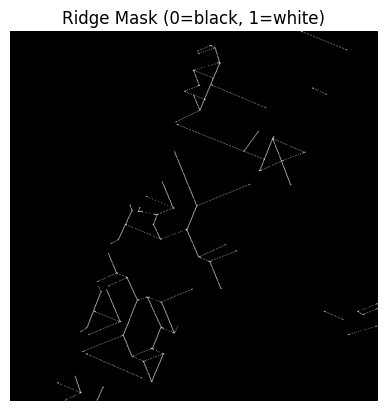

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

mask = Image.open("29.955597_-90.003119_nearmap_rgb_mask.png")
mask_np = np.array(mask)

plt.imshow(mask_np, cmap='gray', vmin=0, vmax=1)
plt.title("Ridge Mask (0=black, 1=white)")
plt.axis('off')
plt.show()


In [8]:
print("Unique values in mask:", np.unique(mask_np))


Unique values in mask: [0 1]


In [9]:
# Scale mask to 0–255 for proper visualization
mask_255 = mask.point(lambda x: x * 255)
mask_255.save(r'29.955597_-90.003119_nearmap_rgb_mask.png')


In [19]:
import numpy as np
import cv2
from skimage.morphology import skeletonize
from PIL import Image

def clean_connect_thicken_mask(mask_path, output_path, kernel_size=4):
    # Load mask and binarize
    mask = np.array(Image.open(mask_path).convert("L"))
    binary = (mask > 0).astype(np.uint8)

    # 1. Skeletonize to get clean 1-pixel lines
    skeleton = skeletonize(binary).astype(np.uint8)

    # 2. Morphological closing to connect tiny gaps
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    connected = cv2.morphologyEx(skeleton, cv2.MORPH_CLOSE, kernel)

    # 3. Dilate to make it thicker (model learns better)
    thick = cv2.dilate(connected, kernel, iterations=1)

    # Save as 0–255 mask
    Image.fromarray(thick * 255).save(output_path)
    print(f"✅ Cleaned + connected + thickened saved to {output_path}")




# Example use
clean_connect_thicken_mask("29.955597_-90.003119_nearmap_rgb_mask.png", "mask_thick.png")


✅ Cleaned + connected + thickened saved to mask_thick.png


In [21]:
import os
import json
from PIL import Image, ImageDraw
import numpy as np
import cv2
from skimage.morphology import skeletonize

def create_mask_from_json(json_path, image_size):
    """Returns binary ridge mask from a JSON file."""
    with open(json_path) as f:
        data = json.load(f)

    mask = Image.new("L", image_size, 0)
    draw = ImageDraw.Draw(mask)

    for shape in data.get("shapes", []):
        label = shape.get("label", "").strip().lower()
        if label == "ridge":
            try:
                points = [tuple(map(float, pt)) for pt in shape["points"]]
                draw.polygon(points, outline=1, fill=1)
            except Exception as e:
                print(f"⚠️ Failed to draw polygon in {json_path}: {e}")

    return np.array(mask)

def clean_connect_thicken(mask, kernel_size=3):
    """Skeleton → Closing → Dilation"""
    binary = (mask > 0).astype(np.uint8)
    
    # Skeletonize
    skeleton = skeletonize(binary).astype(np.uint8)
    
    # Closing (connect small gaps)
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    connected = cv2.morphologyEx(skeleton, cv2.MORPH_CLOSE, kernel)
    
    # Dilation (thicken lines)
    thick = cv2.dilate(connected, kernel, iterations=1)

    return thick * 255  # Return as 0–255 image

def process_folder(json_folder, image_folder, output_mask_folder, image_ext=".tif"):
    os.makedirs(output_mask_folder, exist_ok=True)

    json_files = [f for f in os.listdir(json_folder) if f.endswith(".json")]

    for json_file in json_files:
        basename = os.path.splitext(json_file)[0]
        image_path = os.path.join(image_folder, basename + image_ext)
        json_path = os.path.join(json_folder, json_file)
        output_path = os.path.join(output_mask_folder, basename + "_mask.png")

        # Get image size
        if not os.path.exists(image_path):
            print(f"⚠️ Image not found: {image_path}")
            continue
        try:
            with Image.open(image_path) as img:
                image_size = img.size
        except:
            print(f"❌ Failed to open image: {image_path}")
            continue

        # Create initial mask and apply post-processing
        mask = create_mask_from_json(json_path, image_size)
        thickened = clean_connect_thicken(mask)

        # Save
        Image.fromarray(thickened).save(output_path)
        print(f"✅ Processed: {json_file} → {output_path}")

# Example usage
if __name__ == "__main__":
    process_folder(
        json_folder=r"train/annotation",           # folder with JSON files
        image_folder=r"train/image",          # folder with matching .tif files
        output_mask_folder=r"train/masks",         # where final masks go
        image_ext=".tif"                          # extension of RGB images
    )


✅ Processed: 29.1512553_-81.05048490000001_nearmap_rgb.json → train/masks\29.1512553_-81.05048490000001_nearmap_rgb_mask.png
✅ Processed: 29.215745499999997_-81.1223756_nearmap_rgb.json → train/masks\29.215745499999997_-81.1223756_nearmap_rgb_mask.png
✅ Processed: 29.2214679_-98.64841159999999_nearmap_rgb.json → train/masks\29.2214679_-98.64841159999999_nearmap_rgb_mask.png
✅ Processed: 29.398555199999997_-95.0491078_nearmap_rgb.json → train/masks\29.398555199999997_-95.0491078_nearmap_rgb_mask.png
✅ Processed: 29.496287499999998_-98.6787008_nearmap_rgb.json → train/masks\29.496287499999998_-98.6787008_nearmap_rgb_mask.png
✅ Processed: 29.497318300000003_-95.92321249999999_nearmap_rgb.json → train/masks\29.497318300000003_-95.92321249999999_nearmap_rgb_mask.png
✅ Processed: 29.4996988_-95.9133983_nearmap_rgb.json → train/masks\29.4996988_-95.9133983_nearmap_rgb_mask.png
✅ Processed: 29.5270351_-95.82233500000001_nearmap_rgb.json → train/masks\29.5270351_-95.82233500000001_nearmap_rgb_m

In [1]:
from ridge_dataset import RidgeSegmentationDataset
from transforms import SimpleSegmentationTransform  # assuming you have albumentations transforms

dataset = RidgeSegmentationDataset(
    image_dir="train/image",
    mask_dir="train/masks",
    transform=SimpleSegmentationTransform(512)
)
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=4, shuffle=True)
img, mask = next(iter(loader))
print(img.shape, mask.shape)


c:\Users\adity\miniconda3\envs\pytorch-gpu-env\lib\site-packages\albumentations\__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.17). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


torch.Size([4, 3, 512, 512]) torch.Size([4, 512, 512])
